In [1]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.ticker as ticker
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import (MultipleLocator, FormatStrFormatter,
                               AutoMinorLocator)
plt.rcParams.update({'font.size': 12})
#import seaborn as sns
import cmath
import math 
from numpy.linalg import inv
from matplotlib.lines import Line2D

def custom_plot_single(fig, ax1, 
                       x_lst, y_lst, label_lst, xlim, ylim, label,pltname,
                       color=['k','r','b','g','o','c','m','y'],
                       linestyle=['solid','dashed','solid','dashed','solid','dashed'],
                       markertype=[None,None,'o','^','o','^'],
                       fillstyle=['none','none','none','none','full','full'],
                       linewidth=20*[3],
                       markevery=[450,30,50,40,56,72,63,95],
                       show_legend=True,
                       plt_outside=False, y_logscale = False, fontsize=30, spine_edgecolor='k'):
    
    fig.patch.set_facecolor('white')
    ax1.patch.set_facecolor('white')
    #color[len(x_lst)-1] = 'gray'
    for p in range(0, len(x_lst)):
        ax1.plot(x_lst[p], y_lst[p], color[p],
                 linewidth=linewidth[p],
                 linestyle=linestyle[p],
                 marker=markertype[p],
                 fillstyle=fillstyle[p],
                 markevery=markevery[p],
                 markersize=8,
                 label=label_lst[p])
    if(show_legend):
        ax1.legend(prop={'size': 24},loc='best')
    ax1.tick_params(which='minor', width=2, length=4, color=spine_edgecolor)
    ax1.tick_params(which='major', width=2, length=8, color=spine_edgecolor)

    #ax1.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    #ax1.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    if(show_legend):
        ax1.legend(prop={'size': 24},loc='best',shadow=True)
    if (y_logscale):
        ax1.set_yscale('log')
    ax1.set_ylim(ylim[0],ylim[1])
    ax1.set_xlim(xlim[0],xlim[1])
    ax1.set_xlabel(label[0], fontsize=fontsize)#, fontdict=dict(weight='bold'))
    ax1.set_ylabel(label[1], fontsize=fontsize)#, fontdict=dict(weight='bold'))
    for tick in ax1.xaxis.get_major_ticks():
        tick.label1.set_fontsize(fontsize)

    for tick in ax1.yaxis.get_major_ticks():
        tick.label1.set_fontsize(fontsize)
    for spine in ax1.spines.values():
        spine.set_linewidth(2)  # Increase the frame thickness     
        spine.set_edgecolor(spine_edgecolor)  # Set the spine edge color to red    
        
    if(plt_outside==False):
        plt.savefig(pltname, bbox_inches = "tight")
    return plt,pltname

PrintFigures=True
PointCharge=True


In [2]:
m=20
n=0
nano=1e-9
E_f = -0.2

acc = 0.142e-9
gamma=2.5 #eV
Temp = 298.

def get_radius(acc,m,n):
    return acc*(np.sqrt(3.)/(2*np.pi))*np.sqrt(m**2 + m*n + n**2)

R_cnt = get_radius(acc,m,n)
print('Radius of CNT (nm):', R_cnt/nano)

Eg_min = acc*gamma/R_cnt
print('bandgap, Eg_min/(eV):', Eg_min)


start_step = 0
num_steps = np.array([31,31])
Vgs_notrap = np.linspace(1,-2, num_steps[0])
print('Vgs no trap:', Vgs_notrap)
Vgs_1trap = np.linspace(1,-2, num_steps[1])
print('Vgs 1 trap:', Vgs_1trap)
step_max=np.max(num_steps)

Vds = -0.1

pts=1664
print('num_steps',num_steps)

Quasi_Ef1 = E_f
Quasi_Ef2 = E_f - Vds 

Radius of CNT (nm): 0.7828870314989447
bandgap, Eg_min/(eV): 0.45344984105855446
Vgs no trap: [ 1.   0.9  0.8  0.7  0.6  0.5  0.4  0.3  0.2  0.1  0.  -0.1 -0.2 -0.3
 -0.4 -0.5 -0.6 -0.7 -0.8 -0.9 -1.  -1.1 -1.2 -1.3 -1.4 -1.5 -1.6 -1.7
 -1.8 -1.9 -2. ]
Vgs 1 trap: [ 1.   0.9  0.8  0.7  0.6  0.5  0.4  0.3  0.2  0.1  0.  -0.1 -0.2 -0.3
 -0.4 -0.5 -0.6 -0.7 -0.8 -0.9 -1.  -1.1 -1.2 -1.3 -1.4 -1.5 -1.6 -1.7
 -1.8 -1.9 -2. ]
num_steps [31 31]


In [3]:
foldername = [] 
variable_occupation = []

foldername.append('../simulations/no_charge/EfmDot2')
variable_occupation.append(False)

foldername.append('../simulations/singleCharge/EfmDot2/Zoff4dz')
variable_occupation.append(True)

# foldername.append('../simulations/Efm1/NoCharge')
# label_str.append(r'$E_f=$-1 eV,no trap')
# ZfromCNT.append('None')
# Markertype.append('None')
# Color.append('k--')
# variable_occupation.append(False)

# foldername.append('../simulations/Efm1/ZoffDot0')
# label_str.append(r'$E_f=$-1 eV, $Z_o=0.3$ nm')
# ZfromCNT.append('0.3 nm')
# Color.append('r--')
# Markertype.append('^')
# variable_occupation.append(True)

foldername = np.array(foldername)
num_folders =  np.size(foldername)


In [4]:
print(f"num_folders: {num_folders}, step_max: {step_max}, pts: {pts}")
Y =  np.zeros((num_folders,step_max,pts),dtype=float)
Qout  = np.zeros((num_folders,step_max,pts),dtype=float)
U     = np.zeros((num_folders,step_max,pts),dtype=float)
Ev  = np.zeros((num_folders,step_max,pts),dtype=float)
Ec  = np.zeros((num_folders,step_max,pts),dtype=float)

num_folders: 2, step_max: 31, pts: 1664


In [5]:
for folder in range(num_folders):
    path = foldername[folder] + '/negf/NS_1/step'
    print(f"folder: {folder}, path: {path}")
    
    for f in range(num_steps[folder]):
        s=f
        fileQout = open(path+"%04d_Qout.dat"%(s))
        #print('fileQout',fileQout)
        lst = []
        counter=0
        for line in fileQout:    
            if (counter > 0 and counter < pts+1):
                lst += [line.split()]
            counter  = counter + 1
        y = [x[0] for x in lst]
        qout = [x[1] for x in lst]
        Y[folder][f] = np.asfarray(y)
        Qout[folder][f] = np.asfarray(qout)
        
        fileU = open(path+"%04d_U.dat"%(s))
        lst = []
        counter=0
        for line in fileU:    
            if (counter > -1 and counter < pts+1):
                lst += [line.split()]
            counter  = counter + 1
        u = [x[2] for x in lst]
        U[folder][f] = np.asfarray(u)
        
        # fileNorm = open(path+"%04d_norm.dat"%(s))
        # lst = []
        # counter=0
        # for line in fileNorm:    
        #     if (counter > 0 and counter < pts+1):
        #         lst += [line.split()]
        #     counter  = counter + 1
        # #print(counter)
        # norm = [x[1] for x in lst]
        # Norm[folder][f] = np.asfarray(norm)

Ev = -Eg_min/2. + U
Ec = Eg_min/2. + U
       

folder: 0, path: ../simulations/no_charge/EfmDot2/negf/NS_1/step
folder: 1, path: ../simulations/singleCharge/EfmDot2/Zoff4dz/negf/NS_1/step


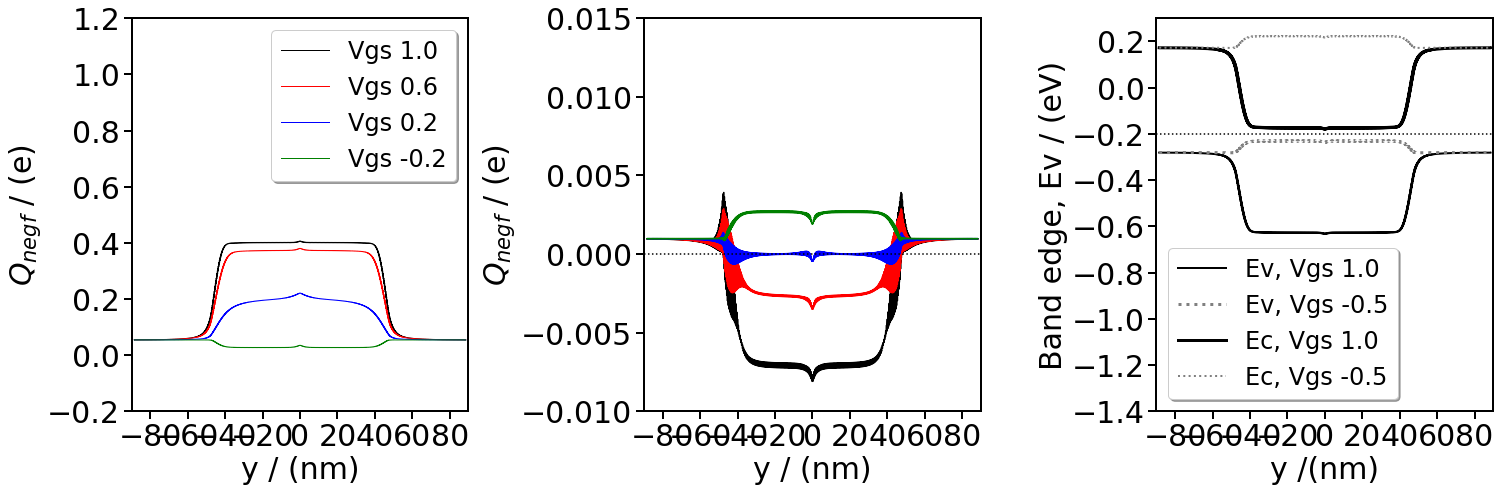

In [10]:
# Dont need this for paper.
fig, ax = plt.subplots(1,3)
fig.set_size_inches(21,7)

#fig.suptitle(r'$V_{ds}=%.1f~$V, Rings= %d'%(Vds, pts), fontsize=30)
if(PrintFigures):
    #range(i,j+1,delta)
    f=1 #folder1 is for 1 trap
    i=0
    j=15
    delta=4    
    plt1,pltname = custom_plot_single(fig, ax[0],
                                     [Y[f][x] for x in range(i,j+1,delta)], 
                                     [-U[f][x] for x in range(i,j+1,delta)],
                                     [r'Vgs %.1f'%(Vgs_1trap[x]) for x in range(i,j+1,delta)],
                                     [-90,90],
                                     [-0.2,1.2],
                                     [r'y / (nm)',
                                      r'$Q_{negf}$ / (e)'],
                                     'Q_zoom.png',
                                     linestyle=['solid']*(j-i+1) + ['dashed']*(j-i+1),
                                     fillstyle=['none']*(j-i+1),
                                     linewidth=[1]*(j-i+1),
                                     markevery=[1]*(j-i+1),
                                     markertype=[None]*(j-i+1),
                       show_legend=True,
                       plt_outside=True, y_logscale=False)

    plt3,pltname = custom_plot_single(fig, ax[1],
                                     [Y[f][x] for x in range(i,j+1,delta)], 
                                     [Qout[f][x] for x in range(i,j+1,delta)],
                                     [r'Vgs %.1f'%(Vgs_1trap[x]) for x in range(i,j+1,delta)],
                                     [-90,90],
                                     [-0.01, .015],
                                     [r'y / (nm)',
                                      r'$Q_{negf}$ / (e)'],
                                     'Q_zoom.png',
                                     markertype=[None]*(j-i+1),
                                     linestyle=['solid']*(j-i+1),
                                     fillstyle=['none']*(j-i+1),
                                     linewidth=[1]*(j-i+1),
                                     markevery=[1]*(j-i+1),
                       show_legend=False,
                       plt_outside=True, y_logscale=False)
    ax[1].axhline(y = 0, color = 'k', linestyle = 'dotted')
    

    plt2,pltname = custom_plot_single(fig, ax[2],
                                     [Y[f][i], Y[f][j],Y[f][i], Y[f][j]], 
                                     [Ev[f][i], Ev[f][j],Ec[f][i], Ec[f][j]],
                                     [r'Ev, Vgs %.1f'%(Vgs_1trap[i]),r'Ev, Vgs %.1f'%(Vgs_1trap[j]),
                                      r'Ec, Vgs %.1f'%(Vgs_1trap[i]),r'Ec, Vgs %.1f'%(Vgs_1trap[j])],
                                     [-90,90],
                                     [-1.4,0.3],
                                     [r'y /(nm)',
                                      r'Band edge, Ev / (eV)'],
                                     'Ev.png',
                                     ['k','gray','k','gray','b'],
                                     linestyle=['solid','dotted','solid','dotted','solid','solid'],
                                     markertype=[None]*5,
                                     markevery=[1,1,1,1,1],
                                     linewidth=[2,3,3,2,2],
                       show_legend=True,
                       plt_outside=True, y_logscale=False)
    ax[2].axhline(y = E_f, color = 'k', linestyle = 'dotted')

fig.tight_layout()
#fig.savefig(filename, dpi='figure', format='png', pad_inches=0.1, facecolor='auto', edgecolor='auto')


In [11]:
print([round(Vgs_notrap[i],1) for i in range(0,31)])
print([round(Vgs_1trap[i],1) for i in range(0,31)])

[1.0, 0.9, 0.8, 0.7, 0.6, 0.5, 0.4, 0.3, 0.2, 0.1, 0.0, -0.1, -0.2, -0.3, -0.4, -0.5, -0.6, -0.7, -0.8, -0.9, -1.0, -1.1, -1.2, -1.3, -1.4, -1.5, -1.6, -1.7, -1.8, -1.9, -2.0]
[1.0, 0.9, 0.8, 0.7, 0.6, 0.5, 0.4, 0.3, 0.2, 0.1, 0.0, -0.1, -0.2, -0.3, -0.4, -0.5, -0.6, -0.7, -0.8, -0.9, -1.0, -1.1, -1.2, -1.3, -1.4, -1.5, -1.6, -1.7, -1.8, -1.9, -2.0]


In [12]:
def create_bandstructure_plot(plt,pltname,Xmin,Xmax,Ymin,Ymax, lw=3, show_axes_labels=True, fs=30, secolor='k', annotate=False):
    i = 0
    j = 11
    k = 20  
    print('Vgs_1trap at ijk:', Vgs_1trap[i], Vgs_1trap[j], Vgs_1trap[k])

    # Create a figure with a fixed size
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_axes([0.18, 0.15, 0.8, 0.8])

    axes_labels = [r'Length along tube / (nm)', r'Band edges, $E_v$ and $E_c$ / (eV)']
    if not show_axes_labels:
        axes_labels = [None,None]

    # Custom plot function for main curves
    plt, pltname = custom_plot_single(fig, ax,
                                      [Y[0][i], Y[0][j], Y[0][k], Y[0][i], Y[0][j], Y[0][k], 
                                       Y[1][i], Y[1][j], Y[1][k], Y[1][i], Y[1][j], Y[1][k]], 
                                      [Ev[0][i], Ev[0][j], Ev[0][k], Ec[0][i], Ec[0][j], Ec[0][k], 
                                       Ev[1][i], Ev[1][j], Ev[1][k], Ec[1][i], Ec[1][j], Ec[1][k]],
                                      [r'(0) Ev, $V_{gs}=$ %.1f'%(Vgs_notrap[i]), r'(0) Ev, $V_{gs}=$ %.1f'%(Vgs_notrap[j]), r'(0) Ev, $V_{gs}=$ %.1f'%(Vgs_notrap[k]),
                                       r'(0) Ec, $V_{gs}=$ %.1f'%(Vgs_notrap[i]), r'(0) Ec, $V_{gs}=$ %.1f'%(Vgs_notrap[j]), r'(0) Ec, $V_{gs}=$ %.1f'%(Vgs_notrap[k]),
                                       r'(1) Ev, $V_{gs}=$ %.1f'%(Vgs_1trap[i]), r'(1) Ev, $V_{gs}=$ %.1f'%(Vgs_1trap[j]), r'(1) Ev, $V_{gs}=$ %.1f'%(Vgs_1trap[k]),
                                       r'(1) Ec, $V_{gs}=$ %.1f'%(Vgs_1trap[i]), r'(1) Ec, $V_{gs}=$ %.1f'%(Vgs_1trap[j]), r'(1) Ec, $V_{gs}=$ %.1f'%(Vgs_1trap[k])],
                                      [Xmin, Xmax],
                                      [Ymin, Ymax],
                                      axes_labels,
                                      pltname,
                                      ['silver', 'silver', 'silver', 'silver', 'silver', 'silver','k', 'k', 'k', 'k', 'k', 'k'],
                                      linestyle=['dashed', 'dashed', 'dashed', 'dashed', 'dashed', 'dashed', 
                                                 'dotted', 'dotted', 'dotted', 'dotted', 'dotted', 'dotted'],
                                      markertype=[None] * 16,
                                      fillstyle=[None] * 16,
                                      markevery=[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
                                      linewidth=[lw]*16,
                                      show_legend=False,
                                      plt_outside=True, y_logscale=False, fontsize=fs, spine_edgecolor=secolor)
    ax.axhline(y=E_f, color='k', linestyle='dotted')
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())

    # Adding text annotations
    if annotate:
        plt.text(-20, -0.13, r'$V_{gs}$ = 1 V', fontsize=30, color='k')
        plt.text(-20, 0.11, r'$V_{gs}$ = -0.1 V', fontsize=30, color='k')    
        plt.text(-20, 0.28, r'$V_{gs}$ = -1 V', fontsize=30, color='k')
        plt.text(-80, -0.18, r'$E_{F}$', fontsize=30, color='k')

    fig.savefig(pltname, bbox_inches="tight", dpi='figure', format='eps', pad_inches=0.1, facecolor='auto', edgecolor='auto')
    
    return fig, ax, pltname

Vgs_1trap at ijk: 1.0 -0.10000000000000009 -1.0
Vgs_1trap at ijk: 1.0 -0.10000000000000009 -1.0


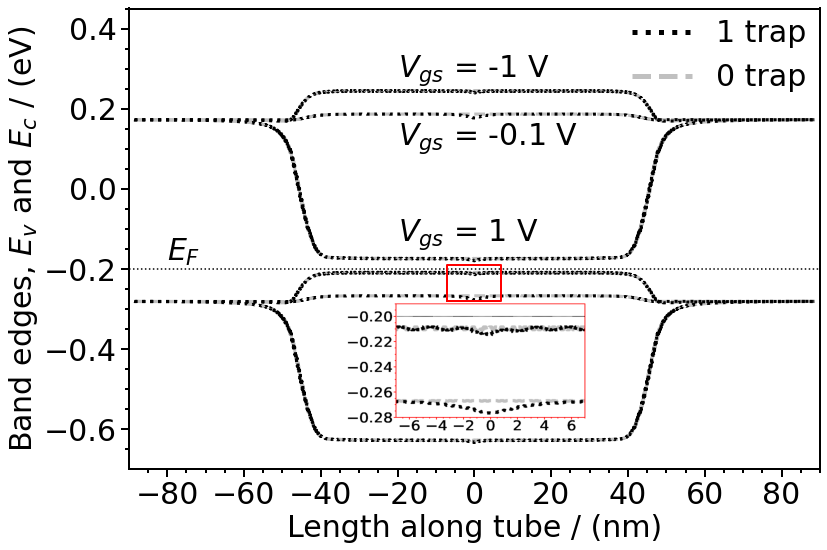

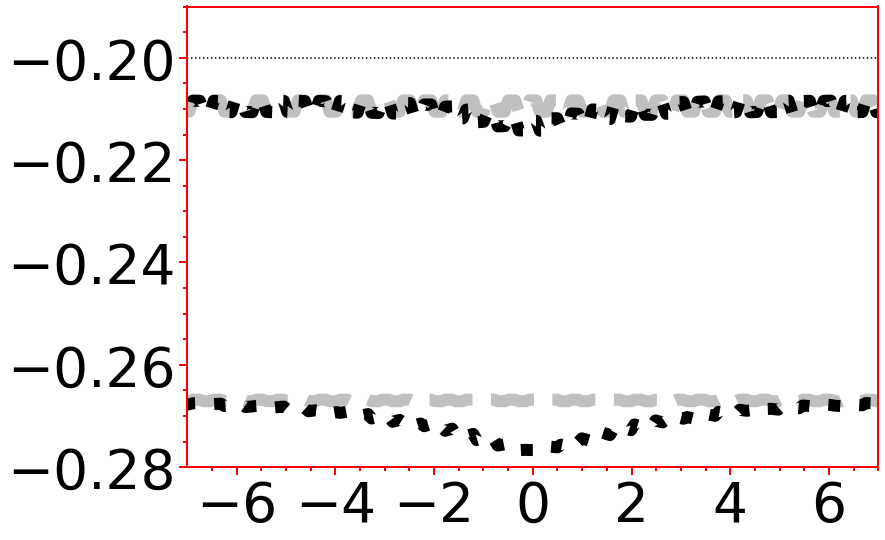

In [13]:
import matplotlib.image as mpimg

if PrintFigures: 
    # First, create the main plot with full region
    fig, ax, pltname = create_bandstructure_plot(plt, pltname='bandedge', Xmin=-90, Xmax=90, Ymin=-0.7, Ymax=0.45, lw=3, fs=30, annotate=True)

    # Draw a red box around the region of interest
    ax.plot([-7, 7, 7, -7, -7], [-0.28, -0.28, -0.19, -0.19, -0.28], 'r-', linewidth=2)  # Red box
    # Add custom legend manually
    legend_handles = [
        Line2D([0], [0], color='black', linestyle=':', lw=5, label='1 trap'),  # Dotted line
        Line2D([0], [0], color='silver', linestyle='--', lw=5, label='0 trap')  # Dashed line
    ]  
    plt.legend(handles=legend_handles, loc='lower right', fontsize=30, frameon=False, 
               bbox_to_anchor=(1.02, 0.76))
    # Now, create the zoomed plot using the same function with the zoomed region
    fig_zoom, ax_zoom, pltname_zoom = create_bandstructure_plot(plt, pltname='bandedge_zoom', Xmin=-7, Xmax=7, Ymin=-0.28, Ymax=-0.19, lw=12, show_axes_labels=False, fs=55, secolor='r', annotate=False)
        
    # Create the inset on the main figure
    inset_ax = fig.add_axes([0.43, 0.21, 0.28, 0.23])  # Position of the inset (X, Y, width, height)    
    img_zoom = mpimg.imread(pltname_zoom)
    inset_ax.imshow(img_zoom)  # Display the zoomed-in portion in the inset    
    inset_ax.set_aspect('auto')  # Adjust aspect ratio as needed
    inset_ax.axis('off')  # Hide the axes for the inset

    fig.savefig('bandedge_1TrapCompare_with_inset.png', bbox_inches="tight", dpi='figure', format='png', pad_inches=0.1, facecolor='auto', edgecolor='auto')

    plt.show()